In [140]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2
import pandas as pd
from astropy.io import fits

In [81]:
np.random.seed(12345)
N=10
x=np.random.normal(0, 1, size=N)

In [82]:
def Chi2(x):
    y=np.sum(x**2)
    return y

In [83]:
ch=Chi2(x)
ch/N # fine.

0.8888825801145908

In [84]:
a=chi2.sf(ch, N)
print("p value is:", a)
a0=0.01
if (a<a0):
    print("hypothesis rejected")
else:
    print("hypothesis accepted")

p value is: 0.5426859966002582
hypothesis accepted


In [85]:
x1=np.random.normal(1,2, size=N)
ch1=Chi2(x1)
ch1/N

6.549113744573323

In [86]:
a=chi2.sf(ch1, N)
print("p value is:", a)
if (a<a0):
    print("hypothesis rejected")
else:
    print("hypothesis accepted")

p value is: 3.264458289526491e-10
hypothesis rejected


In [112]:
np.random.seed(2)
x2=np.random.normal(0.1,1.1, size=N)
ch2=Chi2(x2)
ch2/N

1.698785609561218

In [116]:
a=chi2.sf(ch2, N)
print("p value is:", a)
# Can neither accept nor reject the hypothesis.

p value is: 0.07463312572242896


In [118]:
D={}
D["A"]=x
D["B"]=x1
D["C"]=x2
df=pd.DataFrame(D)
df.to_csv("data/chi2.csv")

# KS test

n 100 
D 0.08326674852986454 
p_value 0.467124170460156 
interpretation no evidence against H0 (fail to reject)


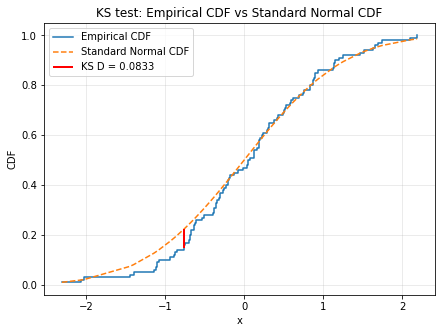

n 100 
D 0.21901620996176263 
p_value 0.00010819478327482311 
interpretation very strong evidence against H0 (reject)


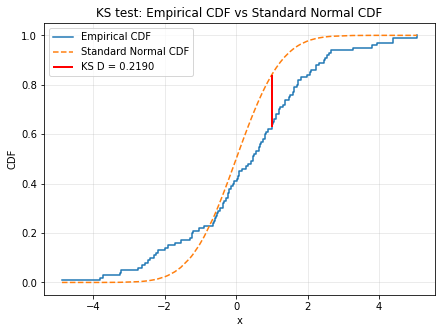

{'n': 100,
 'D': 0.21901620996176263,
 '\np_value': 0.00010819478327482311,
 '\ninterpretation': 'very strong evidence against H0 (reject)'}

In [121]:
from scipy.stats import kstest, norm

def ks_vs_standard_normal(x, alpha=0.05, show_plot=True):
    """
    Perform one-sample KS test of sample x against N(0,1).
    Returns dict with D, p_value, and interpretation.
    If show_plot=True, displays ECDF vs N(0,1) CDF and marks the KS statistic.
    """
    x = np.asarray(x)
    n = x.size
    if n == 0:
        raise ValueError("Empty sample.")
    # KS test against standard normal (mean=0, sd=1)
    D, p_value = kstest(x, 'norm', args=(0, 1))
    # Interpretation using common thresholds
    if p_value <= 0.001:
        evidence = "very strong evidence against H0 (reject)"
    elif p_value <= 0.01:
        evidence = "strong evidence against H0 (reject)"
    elif p_value <= 0.05:
        evidence = "moderate evidence against H0 (reject at 5%)"
    elif p_value <= 0.10:
        evidence = "weak / suggestive evidence against H0 (not significant at 5%)"
    else:
        evidence = "no evidence against H0 (fail to reject)"
    results = {'n': n, 'D': float(D), '\np_value': float(p_value), '\ninterpretation': evidence}
    print('n', n, '\nD', float(D), '\np_value', float(p_value), '\ninterpretation', evidence)

    if show_plot:
        # compute ECDF
        xs = np.sort(x)
        ecdf = np.arange(1, n+1) / n
        # theoretical CDF at sample points
        cdf_vals = norm.cdf(xs, loc=0, scale=1)
        # find location of maximum absolute difference
        diffs = np.abs(ecdf - cdf_vals)
        idx_max = np.argmax(diffs)
        x_ks = xs[idx_max]
        ecdf_ks = ecdf[idx_max]
        cdf_ks = cdf_vals[idx_max]

        plt.figure(figsize=(7,5))
        plt.step(xs, ecdf, where='post', label='Empirical CDF')
        plt.plot(xs, cdf_vals, label='Standard Normal CDF', linestyle='--')
        # mark the KS vertical distance
        plt.vlines(x_ks, min(ecdf_ks, cdf_ks), max(ecdf_ks, cdf_ks),
                   color='red', linestyle='-', linewidth=2, label=f'KS D = {D:.4f}')
        plt.xlabel('x')
        plt.ylabel('CDF')
        plt.title('KS test: Empirical CDF vs Standard Normal CDF')
        plt.legend()
        plt.grid(alpha=0.3)
        plt.show()

    return results

# --- Example usage ---
# Example 1: true standard normal
np.random.seed(1)
data = np.random.normal(0, 1, size=100)
(ks_vs_standard_normal(data))

# Example 2: non-normal (shifted mean)
# data2 = np.random.normal(0.5, 1, size=200)
# data2=np.random.random(10)-0.5
data2=np.random.normal(0, 2, size=100)
(ks_vs_standard_normal(data2))


n 10 
D 0.20520465373496755 
p_value 0.7216796309248583 
interpretation no evidence against H0 (fail to reject)


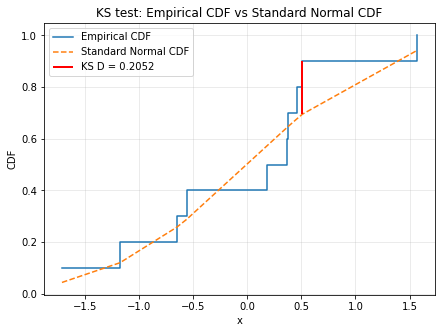

n 30 
D 0.11076181597453011 
p_value 0.8164337165246949 
interpretation no evidence against H0 (fail to reject)


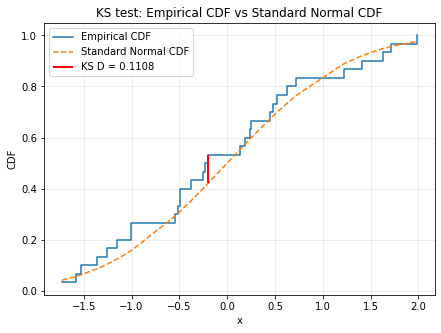

n 100 
D 0.07958193393205293 
p_value 0.5249265981774972 
interpretation no evidence against H0 (fail to reject)


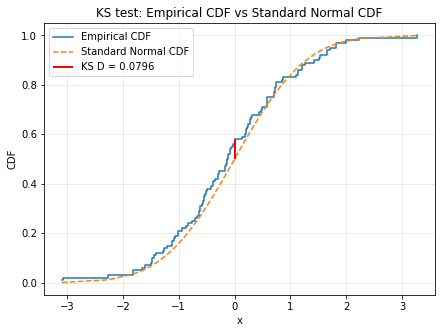

{'n': 100,
 'D': 0.07958193393205293,
 '\np_value': 0.5249265981774972,
 '\ninterpretation': 'no evidence against H0 (fail to reject)'}

In [169]:
np.random.seed(876)
A = np.random.normal(0, 1, size=10)
ks_vs_standard_normal(A)

B = np.random.normal(0, 1, size=30)
ks_vs_standard_normal(B)

C = np.random.normal(0, 1, size=100)
ks_vs_standard_normal(C)

n 10 
D 0.4793660235789755 
p_value 0.012354128666055564 
interpretation moderate evidence against H0 (reject at 5%)


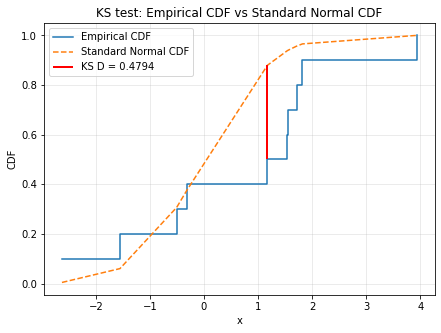

n 30 
D 0.32558991840414986 
p_value 0.002479320955290021 
interpretation strong evidence against H0 (reject)


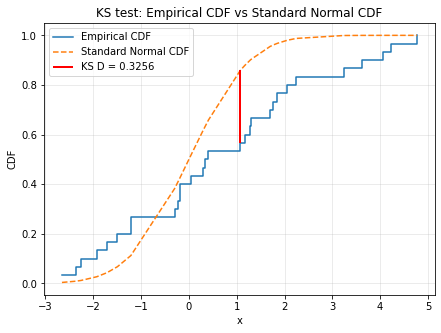

n 100 
D 0.2871499120188119 
p_value 8.574607595720987e-08 
interpretation very strong evidence against H0 (reject)


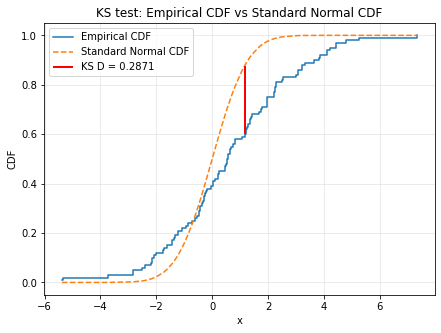

{'n': 100,
 'D': 0.2871499120188119,
 '\np_value': 8.574607595720987e-08,
 '\ninterpretation': 'very strong evidence against H0 (reject)'}

In [170]:
np.random.seed(876)
D = np.random.normal(0.8, 2, size=10)
ks_vs_standard_normal(D)

E = np.random.normal(0.8, 2, size=30)
ks_vs_standard_normal(E)

F = np.random.normal(0.8, 2, size=100)
ks_vs_standard_normal(F)

In [171]:
cols = [
    fits.Column(name='A', array=np.array([A], dtype=object), format='PD'),  # P = variable length, J = 32-bit int
    fits.Column(name='B', array=np.array([B], dtype=object), format='PD'),
    fits.Column(name='C', array=np.array([C], dtype=object), format='PD'),
    fits.Column(name='D', array=np.array([D], dtype=object), format='PD'),
    fits.Column(name='E', array=np.array([E], dtype=object), format='PD'),
    fits.Column(name='F', array=np.array([F], dtype=object), format='PD')
]

In [172]:
hdu = fits.BinTableHDU.from_columns(cols)
hdu.writeto('data/ks.fits', overwrite=True)

In [173]:
with fits.open("data/ks.fits") as hdul:
    hdul.info()  
    data = hdul[1].data  
    A = data['A'][0] 
    B = data['B'][0]
    C = data['C'][0]
    D = data['D'][0]
    E = data['E'][0]
    F = data['F'][0]


Filename: data/ks.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1                1 BinTableHDU     20   1R x 6C   [PD(10), PD(30), PD(100), PD(10), PD(30), PD(100)]   


In [174]:
A

array([-0.65251213,  0.38024738, -0.55926378, -1.71291923,  0.50948928,
       -1.17697782,  0.37035086,  0.18591172,  0.4554018 ,  1.56895894])

n 10 
D 0.20520465373496755 
p_value 0.7216796309248583 
interpretation no evidence against H0 (fail to reject)


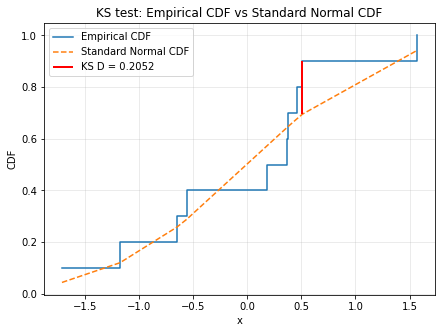

n 30 
D 0.11076181597453011 
p_value 0.8164337165246949 
interpretation no evidence against H0 (fail to reject)


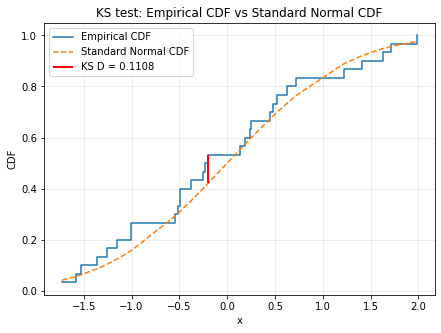

n 100 
D 0.07958193393205293 
p_value 0.5249265981774972 
interpretation no evidence against H0 (fail to reject)


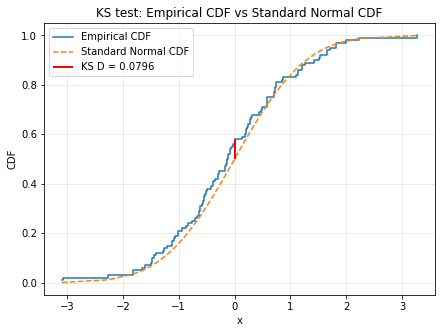

n 10 
D 0.4793660235789755 
p_value 0.012354128666055564 
interpretation moderate evidence against H0 (reject at 5%)


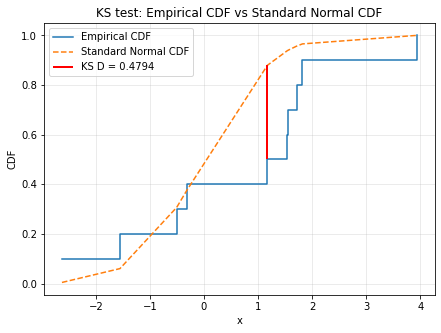

n 30 
D 0.32558991840414986 
p_value 0.002479320955290021 
interpretation strong evidence against H0 (reject)


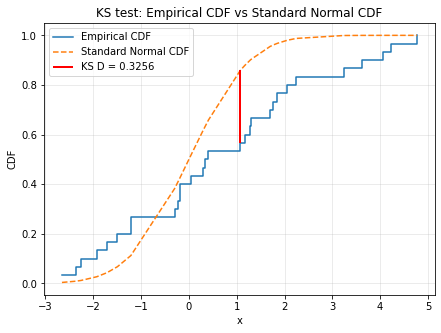

n 100 
D 0.2871499120188119 
p_value 8.574607595720987e-08 
interpretation very strong evidence against H0 (reject)


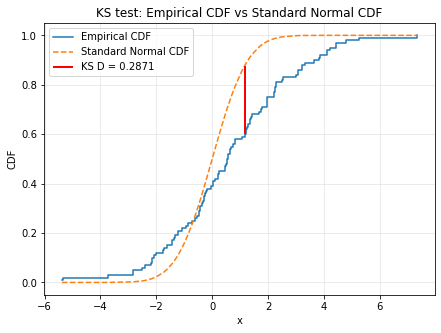

{'n': 100,
 'D': 0.2871499120188119,
 '\np_value': 8.574607595720987e-08,
 '\ninterpretation': 'very strong evidence against H0 (reject)'}

In [175]:
ks_vs_standard_normal(A)

ks_vs_standard_normal(B)

ks_vs_standard_normal(C)
ks_vs_standard_normal(D)

ks_vs_standard_normal(E)

ks_vs_standard_normal(F)
